# Google Play Store Analysis
**Hamed Dhiaa · Python / pandas / Matplotlib**

An exploratory analysis of app categories, ratings, pricing, install bands and supplied review-sentiment scores. Adapted from a DataCamp project using the two CSV files in the original archive.

This is a historical dataset, not a live view of Google Play. App update dates extend to August 2018; they do not establish the collection date. Findings describe this sample and do not establish market share, causation, revenue or app quality.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams.update({"figure.dpi": 120, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titleweight": "bold"})
BLUE, TEAL, GOLD = "#245d80", "#229b91", "#d99538"
raw_apps = pd.read_csv("datasets/apps.csv")
raw_reviews = pd.read_csv("datasets/user_reviews.csv")

def clean_apps(frame):
    result = frame.drop(columns=[x for x in frame if x.startswith("Unnamed:")]).drop_duplicates().copy()
    result["Installs"] = pd.to_numeric(result["Installs"].astype(str).str.replace(r"[+,]", "", regex=True), errors="raise")
    result["Price"] = pd.to_numeric(result["Price"].astype(str).str.replace("$", "", regex=False), errors="raise")
    for col in ["Rating", "Size", "Reviews"]:
        result[col] = pd.to_numeric(result[col], errors="raise")
    if result["App"].isna().any() or not result["App"].is_unique:
        raise ValueError("App names must be present and unique before joining reviews.")
    return result

apps = clean_apps(raw_apps)
category_counts = apps["Category"].value_counts()
rated = apps.dropna(subset=["Rating"])
paid = apps.loc[apps["Type"].eq("Paid")]
print(f"{len(apps):,} apps | {apps.Category.nunique()} categories | {len(rated):,} rated apps")
print(f"Mean rating: {rated.Rating.mean():.3f} / 5 (unweighted across rated apps)")
display(pd.DataFrame({"Missing values": apps.isna().sum()}).query("`Missing values` > 0"))
display(apps.sample(5, random_state=42))

9,659 apps | 33 categories | 8,196 rated apps
Mean rating: 4.173 / 5 (unweighted across rated apps)


,Missing values
Rating,1463
Size,1227
Current Ver,8
Android Ver,2


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
3495,Guns'n'Glory Zombies Premium,FAMILY,4.1,313,34.0,5000,Paid,2.99,Everyone 10+,Strategy,"July 15, 2016",1.1.5,2.3.3 and up
8740,Doorstep EU,NEWS_AND_MAGAZINES,4.5,67,12.0,1000,Free,0.00,Everyone,News & Magazines,"June 26, 2018",1.8,4.1 and up
3100,UNO ™ & Friends,GAME,4.1,1728557,NaN,50000000,Free,0.00,Everyone,Card,"September 20, 2017",Varies with device,Varies with device
3862,YouTube TV - Watch & Record Live TV,FAMILY,4.4,38517,17.0,1000000,Free,0.00,Teen,Entertainment,"August 2, 2018",2.29.2,5.0 and up
3686,AT&T Digital Life,LIFESTYLE,4.1,10067,NaN,1000000,Free,0.00,Everyone,Lifestyle,"December 7, 2017",Varies with device,4.3 and up


## 1. Categories and ratings
Category counts measure representation within the supplied sample. The mean rating gives each rated app equal weight; it is not an average of all individual user ratings. Missing ratings are excluded rather than filled with zero.

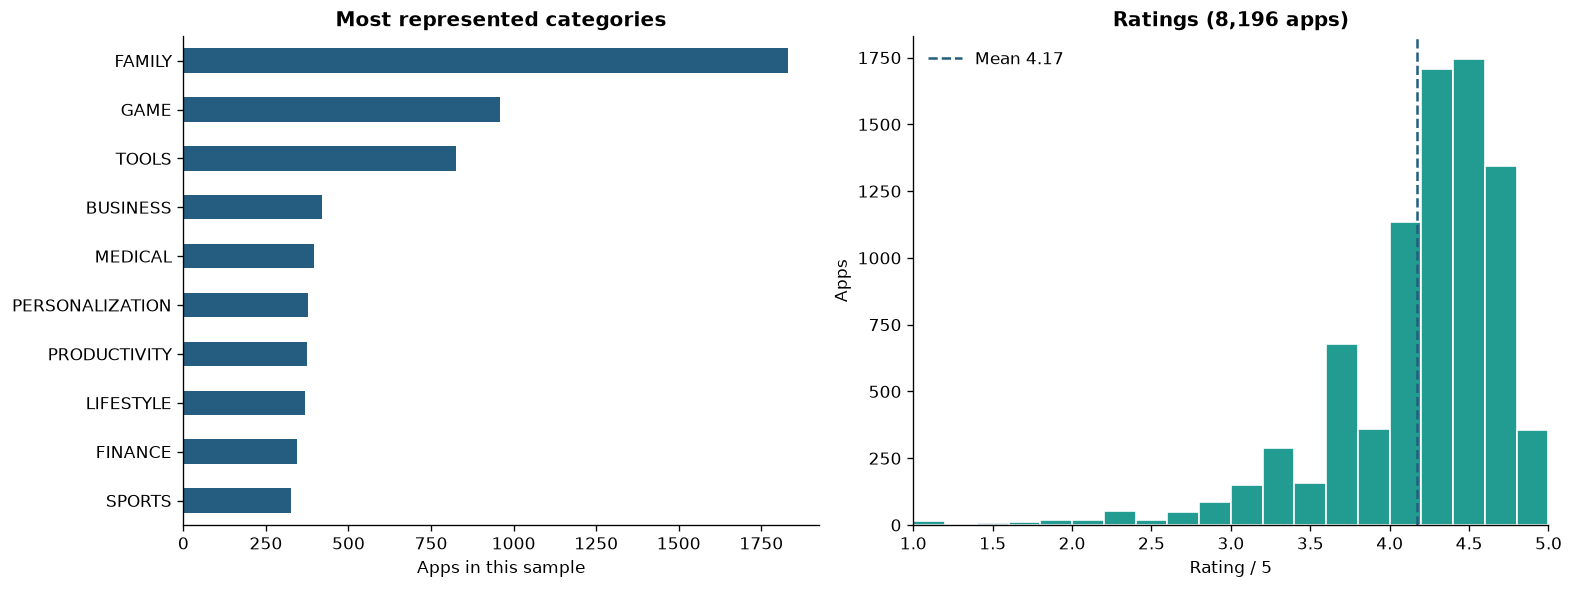

,Apps
Category,
FAMILY,1832
GAME,959
TOOLS,827
BUSINESS,420
MEDICAL,395
PERSONALIZATION,376
PRODUCTIVITY,374
LIFESTYLE,369
FINANCE,345


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), layout="constrained")
category_counts.head(10).sort_values().plot.barh(ax=axes[0], color=BLUE)
axes[0].set(title="Most represented categories", xlabel="Apps in this sample", ylabel="")
axes[1].hist(rated.Rating, bins=np.linspace(1, 5, 21), color=TEAL, edgecolor="white")
axes[1].axvline(rated.Rating.mean(), color=BLUE, linestyle="--", label=f"Mean {rated.Rating.mean():.2f}")
axes[1].set(title=f"Ratings ({len(rated):,} apps)", xlabel="Rating / 5", ylabel="Apps", xlim=(1, 5))
axes[1].legend(frameon=False)
fig.savefig("categories_and_ratings.png", dpi=160, facecolor="white")
plt.show()
display(category_counts.rename("Apps").to_frame().head(10))

## 2. Size, price and ratings
The size comparison uses every row with a known size and rating. The price comparison uses paid apps with a rating, without requiring size to be present. These are associations, not evidence that size or price changes ratings.

The full price range is retained. A logarithmic price axis makes the expensive observations visible without calling them fraudulent or removing them arbitrarily. Size is treated as MB, following the source exercise's description.

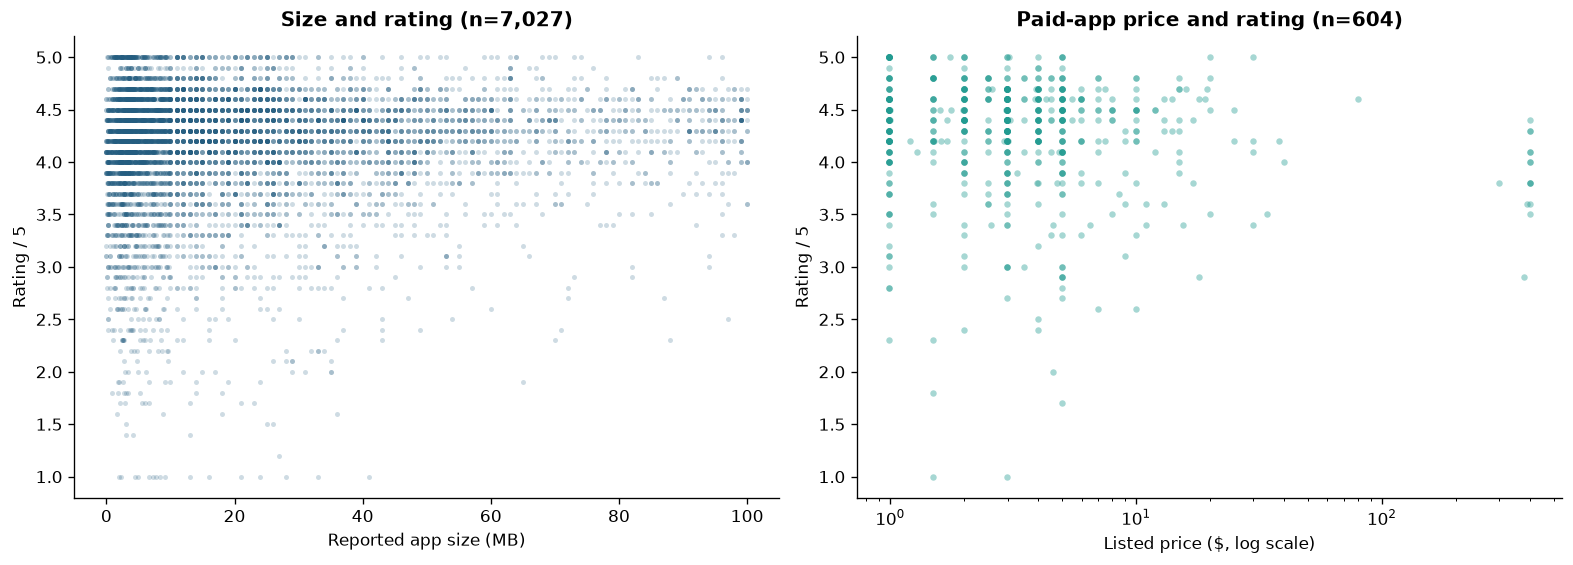

,Apps,Median_price,Maximum_price
Category,,,
EVENTS,1,109.990,109.99
FINANCE,17,28.990,399.99
BOOKS_AND_REFERENCE,28,5.045,6.49
BUSINESS,12,4.990,89.99
MEDICAL,83,4.990,200.00
LIFESTYLE,19,4.990,400.00
PARENTING,2,4.790,4.99
FOOD_AND_DRINK,2,4.240,4.99
ENTERTAINMENT,2,3.990,4.99


In [3]:
size_rated = apps.dropna(subset=["Size", "Rating"])
paid_rated = paid.dropna(subset=["Rating"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6), layout="constrained")
axes[0].scatter(size_rated.Size, size_rated.Rating, s=9, alpha=0.22, color=BLUE, linewidths=0)
axes[0].set(title=f"Size and rating (n={len(size_rated):,})", xlabel="Reported app size (MB)", ylabel="Rating / 5", ylim=(0.8, 5.2))
axes[1].scatter(paid_rated.Price, paid_rated.Rating, s=15, alpha=0.4, color=TEAL, linewidths=0)
axes[1].set(xscale="log", title=f"Paid-app price and rating (n={len(paid_rated):,})", xlabel="Listed price ($, log scale)", ylabel="Rating / 5", ylim=(0.8, 5.2))
fig.savefig("size_and_price.png", dpi=160, facecolor="white")
plt.show()
display(paid.groupby("Category").agg(Apps=("App", "size"), Median_price=("Price", "median"), Maximum_price=("Price", "max")).sort_values("Median_price", ascending=False))

## 3. Free versus paid install bands
`Installs` records the lower bound of a displayed band (for example, `10,000+` becomes 10,000), not an exact download count. Zero-install entries are retained with a symmetric-log axis that is linear near zero. Differences may reflect age, category, promotion and sampling; this comparison does not measure revenue or prove a pricing effect.

,Apps,Median_install_lower_bound,Zero_install_entries
Type,,,
Free,8903,100000.0,5
Paid,756,1000.0,10


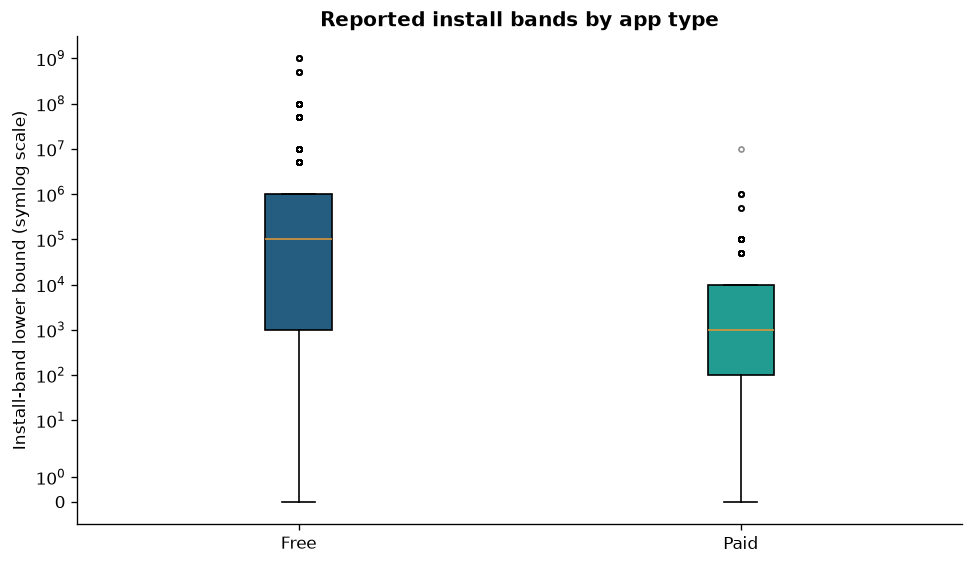

In [4]:
types = ["Free", "Paid"]
install_summary = apps.groupby("Type").agg(Apps=("App", "size"), Median_install_lower_bound=("Installs", "median"), Zero_install_entries=("Installs", lambda x: int(x.eq(0).sum())))
display(install_summary)
fig, ax = plt.subplots(figsize=(8, 4.6), layout="constrained")
bp = ax.boxplot([apps.loc[apps.Type.eq(t), "Installs"] for t in types], tick_labels=types, patch_artist=True, flierprops={"markersize": 3, "alpha": 0.25})
for box, color in zip(bp["boxes"], [BLUE, TEAL]): box.set_facecolor(color)
for median in bp["medians"]: median.set_color(GOLD)
ax.set(yscale="symlog", ylabel="Install-band lower bound (symlog scale)", title="Reported install bands by app type")
fig.savefig("install_bands.png", dpi=160, facecolor="white")
plt.show()

## 4. Review sentiment, with join and sampling checks
These sentiment labels and scores were supplied with the data; this project does not train or validate a sentiment model. Rows need nonblank review text, a supplied sentiment label and a numeric polarity score.

The primary analysis removes exact duplicate rows across all supplied review fields. There are no review IDs, so identical records cannot be proven to represent the same review; an undeduplicated sensitivity table is included. App names are unique in the app table, and a validated many-to-one join prevents multiplying review rows.

We report both review-weighted polarity and an app-level summary that gives each represented app equal weight. Apps and reviews were not randomly sampled; free/paid differences do not prove differences in quality.

,Rows / apps
Raw review rows,64295
Usable rows before deduplication,37427
Exact duplicates removed from usable rows,7735
Usable distinct rows,29692
Matched rows,28250
Unmatched rows,1442
Represented apps,816


,Reviews,Apps,Mean_polarity,Median_polarity
Type,,,,
Free,27947,807,0.187948,0.155556
Paid,303,9,0.218194,0.216667


,All usable matched rows,Distinct matched rows,Equal weight per app
Type,,,
Free,0.180,0.188,0.199
Paid,0.229,0.218,0.178


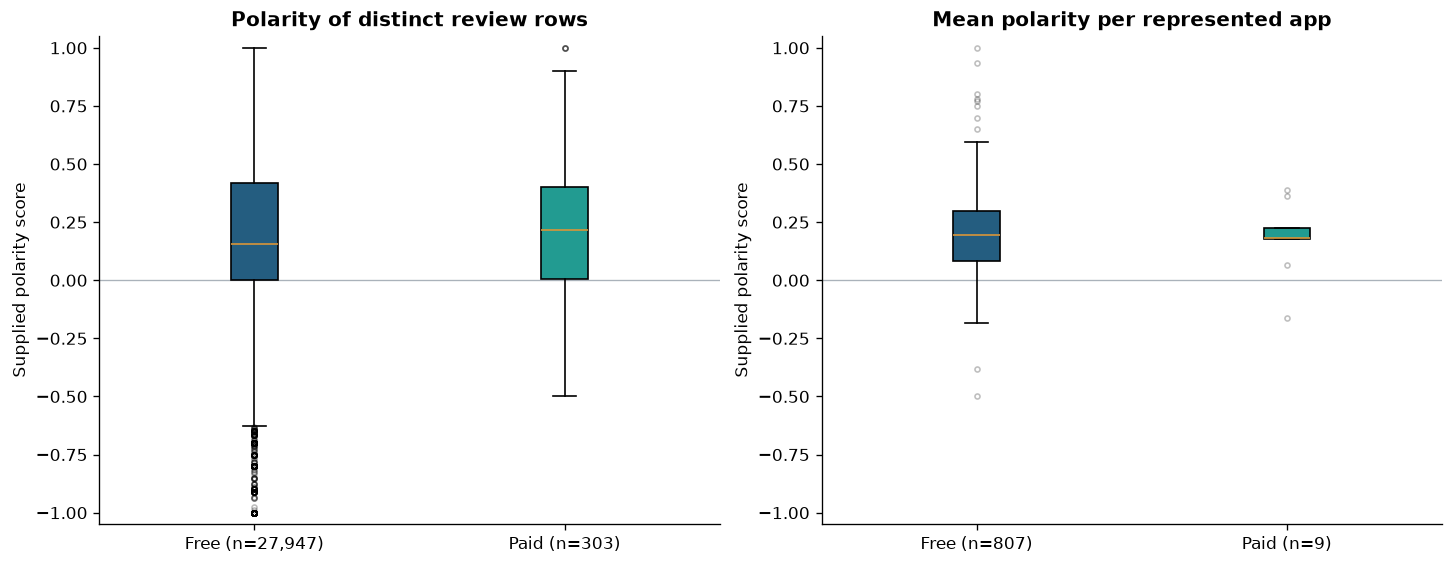

In [5]:
usable_reviews = raw_reviews.dropna(subset=["Review", "Sentiment", "Sentiment_Polarity"]).copy()
usable_reviews = usable_reviews.loc[usable_reviews.Review.str.strip().ne("")].copy()
reviews = usable_reviews.drop_duplicates().copy()
joined = reviews.merge(apps[["App", "Type"]], on="App", how="left", validate="many_to_one", indicator=True)
matched = joined.loc[joined["_merge"].eq("both")].copy()
raw_matched = usable_reviews.merge(apps[["App", "Type"]], on="App", how="inner", validate="many_to_one")
audit = pd.Series({"Raw review rows": len(raw_reviews), "Usable rows before deduplication": len(usable_reviews), "Exact duplicates removed from usable rows": len(usable_reviews)-len(reviews), "Usable distinct rows": len(reviews), "Matched rows": len(matched), "Unmatched rows": int(joined["_merge"].eq("left_only").sum()), "Represented apps": matched.App.nunique()}, name="Rows / apps")
display(audit.to_frame())
review_summary = matched.groupby("Type").agg(Reviews=("App", "size"), Apps=("App", "nunique"), Mean_polarity=("Sentiment_Polarity", "mean"), Median_polarity=("Sentiment_Polarity", "median"))
app_polarity = matched.groupby(["App", "Type"], as_index=False).agg(Mean_polarity=("Sentiment_Polarity", "mean"), Review_rows=("App", "size"))
sensitivity = pd.concat({"All usable matched rows": raw_matched.groupby("Type").Sentiment_Polarity.mean(), "Distinct matched rows": matched.groupby("Type").Sentiment_Polarity.mean(), "Equal weight per app": app_polarity.groupby("Type").Mean_polarity.mean()}, axis=1)
display(review_summary)
display(sensitivity.round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), layout="constrained")
for ax, frame, field, title in [(axes[0], matched, "Sentiment_Polarity", "Polarity of distinct review rows"), (axes[1], app_polarity, "Mean_polarity", "Mean polarity per represented app")]:
    groups = [frame.loc[frame.Type.eq(t), field] for t in types]
    bp = ax.boxplot(groups, tick_labels=[f"{t} (n={len(g):,})" for t, g in zip(types, groups)], patch_artist=True, flierprops={"markersize": 3, "alpha": 0.25})
    for box, color in zip(bp["boxes"], [BLUE, TEAL]): box.set_facecolor(color)
    for median in bp["medians"]: median.set_color(GOLD)
    ax.axhline(0, color="#aab2ba", linewidth=0.8, zorder=0)
    ax.set(title=title, ylabel="Supplied polarity score", ylim=(-1.05, 1.05))
fig.savefig("review_sentiment.png", dpi=160, facecolor="white")
plt.show()

## Findings and limitations
The summary below is calculated from the data on every run. Counts describe this archive, not today's store. A list price is not revenue; install bands are not exact totals; and review polarity is neither verified sentiment accuracy nor a measure of app quality.

Missing ratings and sizes restrict their respective plots. Review coverage is much smaller than app coverage, and review frequency varies by app. App-name matching can also conflate unrelated products with the same name; package identifiers are unavailable.

**Provenance:** adapted from the supplied DataCamp Google Play Store project. The two source CSV files are preserved unchanged. Source-data rights remain with their respective owners. No live scraping or external data download is needed to run this notebook.

In this sample, review-weighted mean polarity is higher for paid apps (0.218 versus 0.188), but equal weighting by app reverses the comparison (0.178 versus 0.199). Only **9 paid apps** have matched usable reviews, compared with 807 free apps. This sensitivity is a reason to avoid a broad claim that paid apps receive better feedback.

In [6]:
print(f"Largest sampled category: {category_counts.index[0]} ({category_counts.iloc[0]:,} apps).")
print(f"Mean rating: {rated.Rating.mean():.2f}/5 across {len(rated):,} rated apps; {apps.Rating.isna().sum():,} missing.")
print(f"Paid apps: {len(paid):,} ({len(paid)/len(apps):.1%}); median listed paid price: ${paid.Price.median():.2f}.")
print(f"Sentiment analysis: {len(matched):,} distinct review rows covering {matched.App.nunique():,} apps.")
print("Free/paid comparisons are descriptive; no causal or market-wide claims are made.")

Largest sampled category: FAMILY (1,832 apps).
Mean rating: 4.17/5 across 8,196 rated apps; 1,463 missing.
Paid apps: 756 (7.8%); median listed paid price: $2.99.
Sentiment analysis: 28,250 distinct review rows covering 816 apps.
Free/paid comparisons are descriptive; no causal or market-wide claims are made.
